---
# **Práctica 1**: *Exploración de Niveles del lenguaje* 🔭
---
### **Alumno**:  Roberto Samuel Sanchez Rosas

### **Fonética**

1. Con base en el sistema de búsqueda visto en la [práctica 1](https://github.com/umoqnier/cl-2026-2-lab/blob/main/notebooks/1_niveles_linguisticos_I.ipynb), dónde se recibe una palabra ortográfica y devuelve sus transcripciones fonológicas, proponga una solución para los casos en que la palabra buscada no se encuentra en el lexicón/diccionario.
    - ¿Cómo devolver o **aproximar** su transcripción fonológica?
    - Reutiliza el sistema de búsqueda visto en clase y mejóralo con esta funcionalidad.
    - Muestra al menos tres ejemplos

Para esta parte primero usaremos el codigo visto en clase para descargar y obtener el corpus del IPA

In [1]:
import http
from collections import defaultdict

import pandas as pd
import requests as r

from rich import print as rprint
from rich.columns import Columns
from rich.panel import Panel
from rich.text import Text

In [2]:
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"

In [3]:
def download_ipa_corpus(iso_lang: str) -> str:
    """Get ipa-dict file from Github

    Parameters:
    -----------
    iso_lang:
        Language as iso code

    Results:
    --------
    dict:
        Dictionary with words as keys and phonetic representation
        as values for a given lang code
    """
    print(f"Downloading {iso_lang}", end="::")
    response = r.get(IPA_URL.format(lang=iso_lang))
    status_code = response.status_code
    print(f"status={status_code}")
    if status_code != http.HTTPStatus.OK:
        print(f"ERROR on {iso_lang} :(")
        return ""
    return response.text

In [4]:
def parse_response(response: str) -> dict:
    """Parse text response from ipa-dict to python dict

    Each row have the format:
    [WORD][TAB]/[IPA]/(, /[IPA]/)?

    Parameters:
    ----------
    response: str
        ipa-dict raw text

    Returns
    -------
    dict:
        A dictionary with the word as key and the phonetic
        representations as value
    """
    ipa_list = response.rstrip().split("\n")
    result = {}
    for item in ipa_list:
        if item == '':
            continue
        item_list = item.split("\t")
        result[item_list[0]] = item_list[1]
    return result

In [5]:
es_data = parse_response(download_ipa_corpus("es_MX"))

####**Solución**
La solución que se me ocurrió para resolver el problema cuando la palabra no se encientra en el lexicón/diccionario es usar CRFs para entrenar un modelo y así **aproximar** su transcripción fonológica, pues hay una analogía entre lo que vimos en la clase de laboratorio ya que queriamos realizar el etiquetado POS a una oracion y para eso debiamos separar la oracion en palabras, de esta manera podemos decir que para este problema queremos encontrar su representacion IPA de una palabra, la cual podemos separar por letras.

In [6]:
def limpiar_transcripciones_ipa(ipa_dict: dict[str, str]):
    """
    Elimina los caracteres / al inicio y final del IPA, ademas de quitar todos los
    caracteres ˈ

    Parameters:
    -----------
    ipa_dict: dict[str, str]
        El diccionario ipa

    Returns:
    -------
    dict[str, str]
        El diccionario ipa donde los valores IPA no incluyen a los caracteres / ni '
    """
    return {k: v.strip("/").replace("ˈ", "") for k, v in ipa_dict.items()}

In [7]:
ipa_esp = limpiar_transcripciones_ipa(es_data)

In [8]:
def word_to_features(word: str):
    features = []
    for i, char in enumerate(word):
        f = {
            "char.lower()": char.lower(),
            "is_first": i == 0,
            "is_last": i == len(word) - 1,
        }

        if i > 0:
            f["prev_char.lower()"] = word[i-1].lower()
        else:
            f["BOS"] = True

        if i < len(word)-1:
            f["next_char.lower()"] = word[i+1].lower()
        else:
            f["EOS"] = True

        features.append(f)

    return features

En esta parte tuve problemas ya que me daba error al comparar las letras de la palabra con su IPA pues en general no se cumple que sean iguales, para solucionar esto le pregunte a *ChatGPT* y me dijo que los rellenara con algun placeholder. Me enfoque en el español ya que el tamaño de letras y el IPA es parecido, mientras que en otros como el ingles esto puede variar demasiado

In [9]:
def alinear_etiquetas(palabra, ipa):
    l_palabra = list(palabra)
    l_ipa = list(ipa)

    # Rellenamos el IPA con '-' hasta que mida lo mismo que la palabra
    while len(l_ipa) < len(l_palabra):
        l_ipa.append('-')

    # En caso raro de que el IPA sea más largo, lo recortamos
    if len(l_ipa) > len(l_palabra):
        l_ipa = l_ipa[:len(l_palabra)]

    return l_ipa

In [10]:
alinear_etiquetas('hielo', ipa_esp['hielo'])

['j', 'e', 'l', 'o', '-']

In [11]:
pip install sklearn-crfsuite

In [12]:
# Preparando datos para el CRF
X = []
y = []

# Para hacer que no tarde mucho, no tomamos a todos los elementos del diccionario
for word, ipa in list(ipa_esp.items())[:20000]:
    X.append(word_to_features(word))
    y.append(alinear_etiquetas(word, ipa))

In [13]:
from sklearn.model_selection import train_test_split
import sklearn_crfsuite

# Dividimos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Configuramos el CRF
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100
)

# Entrenamos
crf.fit(X_train, y_train)

CRF(algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100)

In [14]:
def predecir_palabra(palabra_texto):
    # Convertimos la palabra a features
    features = [word_to_features(palabra_texto)]

    # El modelo predice la secuencia de etiquetas
    prediccion = crf.predict(features)[0] # Tomamos la primera palabra

    # Quitamos los guiones '-' y unimos todo en un string
    ipa_limpio = "".join([sonido for sonido in prediccion if sonido != '-'])

    return ipa_limpio

In [15]:
def get_ipa_transcriptions(word: str, dataset: dict) -> list[str]:
    """Search for a word in an IPA phonetics dict

    Given a word this function return the IPA transcriptions

    Parameters:
    -----------
    word: str
        A word to search in the dataset
    dataset: dict
        A dataset for a given language code

    Returns
    -------
    list[str]:
        List with posible transcriptions if any.
        If the word is not found, an approximated transcription
        predicted by a trained CRF model is returned instead.
    """
    #return dataset.get(word.lower(), '').split(", ")
    return dataset.get(word.lower(), predecir_palabra(word.lower())).split(", ")

In [16]:
# Pruebas con 3 palabras que no estan en el corpus y una que sí.

for word in ['apapachar', 'parangaricutirimicuaro', 'parrillada', 'lluvia']:
    print(f"Palabra: {word}\n\t Resultado: {get_ipa_transcriptions(word, ipa_esp)}\n\t Esta en corpus: {'Sí' if word in ipa_esp else 'No'}")

Palabra: apapachar
	 Resultado: ['apapatʃaɾ']
	 Esta en corpus: No
Palabra: parangaricutirimicuaro
	 Resultado: ['paɾaŋgaɾikutiɾimikwaɾo']
	 Esta en corpus: No
Palabra: parrillada
	 Resultado: ['aɾraiʎaða']
	 Esta en corpus: No
Palabra: lluvia
	 Resultado: ['ʎuβja']
	 Esta en corpus: Sí


### **Morfología**

2. Elige tres lenguas del corpus que pertenezcan a familias lingüísticas distintas
   - Ejemplo: `spa` (Romance), `eng` (Germánica), `hun` (Urálica)
   - Para cada una de las tres lenguas calcula y compara:
       -  **Ratio morfemas / palabra**: El promedio de morfemas que componen las palabras
        -  **Indicé de Flexión / Derivación**: Del total de morfemas, ¿Qué porcentaje son etiquetas de flexión (`100`) y cuáles de derivación (`010`)?

In [17]:
LANGS = {
    "ces": "Czech",
    "eng": "English",
    "fra": "French",
    "hun": "Hungarian",
    "spa": "Spanish",
    "ita": "Italian",
    "lat": "Latin",
    "rus": "Russian",
}
CATEGORIES = {
    "100": "Inflection",
    "010": "Derivation",
    "101": "Inflection, Compound",
    "000": "Root",
    "011": "Derivation, Compound",
    "110": "Inflection, Derivation",
    "001": "Compound",
    "111": "Inflection, Derivation, Compound"
}

In [18]:
response = r.get("https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/spa.word.test.gold.tsv")

In [19]:
def get_track_files(lang: str, track: str = "word") -> list[str]:
    """Genera una lista de nombres de archivo del shared task

    Con base en el idioma y el track obtiene el nombre de los archivos
    para con información reelevante para hacer análisis estadístico.
    Esto es archivos .test y .dev

    Parameters:
    ----------
    lang : str
        Idioma para el cual se generarán los nombres de archivo.
    track : str, optional
        Track del shared task de donde vienen los datos (por defecto es "word").

    Returns:
    -------
    list[str]
        Una lista de nombres de archivo generados para el idioma y la pista especificados.
    """
    return [
        f"{lang}.{track}.test.gold",
        f"{lang}.{track}.dev",
    ]

In [20]:
def get_raw_corpus(files: list) -> list:
    """Descarga y concatena los datos de los archivos tsv desde una URL base.

    Parameters:
    ----------
    files : list
        Lista de nombres de archivos (sin extensión) que se descargarán
        y concatenarán.

    Returns:
    -------
    list
        Una lista que contiene los contenidos descargados y concatenados
        de los archivos tsv.
    """
    result = []
    for file in files:
        #print(f"Downloading {file}.tsv", end=" ")
        response = r.get(f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{file}.tsv")
        #print(f"status={response.status_code}")
        lines = response.text.split("\n")
        result.extend(lines[:-1])
    return result

In [21]:
def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    """Convierte una lista de datos de corpus en un DataFrame

    Parameters:
    ----------
    corpus_list : list
        Lista de líneas del corpus a convertir en DataFrame.
    lang : str
        Idioma al que pertenecen los datos del corpus.

    Returns:
    -------
    pd.DataFrame
        Un DataFrame de pandas que contiene los datos del corpus procesados.
    """
    data_list = []
    for line in corpus_list:
        try:
            word, tagged_data, category = line.split("\t")
        except ValueError:
            # Caso donde no existe la categoria
            word, tagged_data = line.split("\t")
            category = "NOT_FOUND"
        morphemes: list = tagged_data.split()
        data_list.append(
            {"words": word, "morph": morphemes, "category": category, "lang": lang}
        )
    df = pd.DataFrame(data_list)
    df["word_len"] = df["words"].apply(lambda word: len(word))
    df["morph_count"] = df["morph"].apply(lambda list: len(list))
    return df

In [22]:
def obtener_corpus_lenguaje(lang: str):
    """
    Obtiene el corpus del lenguaje en un DataFrame

    Parameters:
    ----------
    lang : str
        Idioma del corpus.

    Returns:
    -------
    pd.DataFrame
        Un DataFrame de pandas que contiene los datos del corpus procesados.
    """

    files = get_track_files(lang)
    raw_spa = get_raw_corpus(files)
    return raw_corpus_to_dataframe(raw_spa, lang=lang)

In [23]:
def limpiar_corpus_lenguaje(df: pd.DataFrame):
    """
    Elimina los caracteres @ en los morfemas del corpus

    Parameters:
    ----------
    df : pd.DataFrame
        El dataFrame de pandas que contiene los datos del corpus procesados.

    Returns:
    -------
    pd.DataFrame
        Un DataFrame de pandas que contiene los datos del corpus procesados con
        los morfemas sin el simbolo @.
    """

    df_morfema_limpio = df.copy()
    df_morfema_limpio['morph'] = df['morph'].apply(lambda lst: [m.replace('@@','') for m in lst if m.replace('@@','')])
    return df_morfema_limpio

In [24]:
# Seleccionamos los corpus de los lenguajes italiano, ruso e inglés.
corpus_ita = limpiar_corpus_lenguaje(obtener_corpus_lenguaje('ita'))
corpus_rus = limpiar_corpus_lenguaje(obtener_corpus_lenguaje('rus'))
corpus_eng = limpiar_corpus_lenguaje(obtener_corpus_lenguaje('eng'))

In [25]:
def ratio_morfemas(df: pd.DataFrame):
    return df["morph_count"].mean()

In [26]:
def mostrar_ratio_morfemas(corpus):
    print(f'Lengua: {LANGS[corpus['lang'][0]]}, Ratio morfemas: {ratio_morfemas(corpus):.2f}')

In [27]:
mostrar_ratio_morfemas(corpus_ita)
mostrar_ratio_morfemas(corpus_rus)
mostrar_ratio_morfemas(corpus_eng)

Lengua: Italian, Ratio morfemas: 2.68
Lengua: Russian, Ratio morfemas: 3.85
Lengua: English, Ratio morfemas: 2.35


In [28]:
def indice_morfemas_flexion_derivacion(df: pd.DataFrame):
    total_morfemas = 0
    flexion = 0
    derivacion = 0

    for _, row in df.iterrows():
        category = row['category']
        morph_count = row['morph_count']  # número de morfemas en esa palabra

        total_morfemas += morph_count
        if category[0] == '1':  # flexión
            flexion += morph_count
        if category[1] == '1':  # derivación
            derivacion += morph_count

    porcentaje_flexion = flexion / total_morfemas * 100
    porcentaje_derivacion = derivacion / total_morfemas * 100

    return {'porcentaje_flexion': porcentaje_flexion, 'porcentaje_derivacion':porcentaje_derivacion}

In [29]:
def mostrar_indices_morfemas_flexion_derivacion(corpus):
    indices = indice_morfemas_flexion_derivacion(corpus)
    p_flexion = indices['porcentaje_flexion']
    p_derivacion = indices['porcentaje_derivacion']
    print(f"Porcentaje de morfemas para {LANGS[corpus['lang'][0]]}")
    print(f"\tFlexivos: {p_flexion:.2f}%")
    print(f"\tDerivativos: {p_derivacion:.2f}%")

In [30]:
mostrar_indices_morfemas_flexion_derivacion(corpus_ita)
mostrar_indices_morfemas_flexion_derivacion(corpus_rus)
mostrar_indices_morfemas_flexion_derivacion(corpus_eng)

Porcentaje de morfemas para Italian
	Flexivos: 88.68%
	Derivativos: 66.65%
Porcentaje de morfemas para Russian
	Flexivos: 93.49%
	Derivativos: 80.15%
Porcentaje de morfemas para English
	Flexivos: 49.33%
	Derivativos: 69.52%


3. Visualización
    - Genera una figura con **subplots** para comparar las lenguas lado a lado.
    - *Plot 1*: Distribución de la longitud de los morfemas
    - *Plot 2*: Distribución de las categorías (flexión, derivación, raíz, etc.)

In [31]:
# Juntamos los corpus en uno solo
df_concatenado = pd.concat([corpus_eng, corpus_ita, corpus_rus])

# Para el Plot 1 de longitud de morfemas usamos Explode para pasar cada
# morfema a una fila distinta
df_morphs = df_concatenado.explode('morph')
df_morphs['morph_len_single'] = df_morphs['morph'].str.len()

In [32]:
df_morphs.head()

,words,morph,category,lang,word_len,morph_count,morph_len_single
0,subsidised,subside,110,eng,10,4,7
0,subsidised,y,110,eng,10,4,1
0,subsidised,ise,110,eng,10,4,3
0,subsidised,ed,110,eng,10,4,2
1,merchandizes,merchandize,100,eng,12,2,11


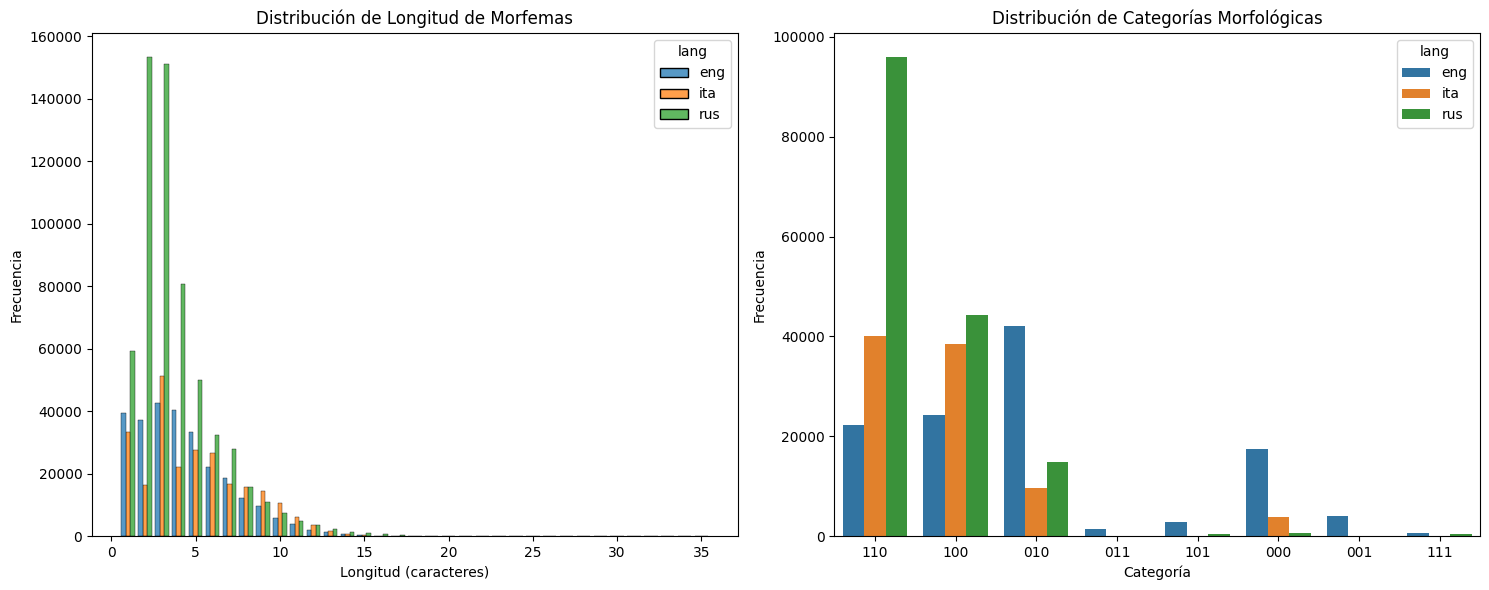

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Juntamos los corpus en uno solo
df_concatenado = pd.concat([corpus_eng, corpus_ita, corpus_rus])

# Para el Plot 1 de longitud de morfemas usamos Explode para pasar cada
# morfema a una fila distinta, ademas agregamos su longitud
df_morphs = df_concatenado.explode('morph')
df_morphs['morph_len'] = df_morphs['morph'].str.len()

# Configurar figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Plot 1
sns.histplot(
    data=df_morphs,
    x='morph_len',
    hue='lang',
    multiple='dodge',
    discrete=True,
    shrink=0.8,
    ax=axes[0]
)
axes[0].set_title('Distribución de Longitud de Morfemas')
axes[0].set_xlabel('Longitud (caracteres)')
axes[0].set_ylabel('Frecuencia')

# Plot 2
sns.countplot(
    data=df_concatenado,
    x='category',
    hue='lang',
    ax=axes[1]
)
axes[1].set_title('Distribución de Categorías Morfológicas')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

4. Con base en esta información, responde la pregunta: *¿Cuál de las tres lenguas se comporta más como una lengua aglutinante y cuál como una lengua aislante?*
    - Justifica tu respuesta usando tus métricas y figuras

In [34]:
CATEGORIES

{'100': 'Inflection',
 '010': 'Derivation',
 '101': 'Inflection, Compound',
 '000': 'Root',
 '011': 'Derivation, Compound',
 '110': 'Inflection, Derivation',
 '001': 'Compound',
 '111': 'Inflection, Derivation, Compound'}

### Respuesta

El ruso es la lengua que muestra el comportamiento más aglutinante pues fue el que obtuvo un mayor ratio de morfemas (3.85, aproximadamente 4) y sabemos que una carateristica de  las lenguas aglutinantes, es que una palabra suele formarse uniendo varios morfemas. Luego en la *distribucion de longitud de morfemas*, el ruso domina con gran diferencia las frecuencias en longitudes de morfemas menores a 6 caracteres, lo cual coincide con la segmentación en morfemas cortos que tienden a tener las lenguas aglutinantes.

Por otro lado, el inglés se clasifica como la lengua con mayor tendencia aislante ya que su promedio de morfemas por palabra (2.35) es el más bajo de las tres lenguas analizadas. Esto refleja una estructura de palabra más simple y con menos elementos añadidos. En la *distribución de categorías morfológicas*, el inglés presenta una distribución más equilibrada entre varias categorías minoritarias, a diferencia del ruso, que concentra la mayor parte de sus casos en la formación de palabras complejas (categoría 110). Además con su porcentaje de morfemas flexivos (49.33%) nos podemos dar cuenta que el inglés no utiliza la morfología de manera intensiva para marcar accidentes gramaticales, prefiriendo el uso de partículas independientes o el orden sintáctico que son características típicas de una lengua aislante.